# Function 3 – Next Evaluation (Week 7)

Load all observed data, identify the current maximum (incumbent), and define our approach for the next evaluation.

In [1]:
import numpy as np
from pathlib import Path

import sys
sys.path.append('../..')

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_3d_scatter_with_distribution,
)

base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')

function_name = 'function_3'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']

X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output]),
])

best_idx = np.argmax(y_observed)
incumbent_input = X_observed[best_idx]
incumbent_output = y_observed[best_idx]

print('=' * 60)
print('FUNCTION 3 – CURRENT MAXIMUM (INCUMBENT)')
print('=' * 60)
print(f'Incumbent input (best-performing configuration): {incumbent_input}')
print(f'Incumbent output (observed maximum):            {incumbent_output:.6f}')
print(f'Number of observations:                          {len(y_observed)}')
print('=' * 60)
formatted_incumbent = '-'.join([f'{x:.6f}' for x in incumbent_input])
print(f'\nFormatted for submission: {formatted_incumbent}')


FUNCTION 3 – CURRENT MAXIMUM (INCUMBENT)
Incumbent input (best-performing configuration): [0.49258141 0.61159319 0.34017639]
Incumbent output (observed maximum):            -0.034835
Number of observations:                          21

Formatted for submission: 0.492581-0.611593-0.340176


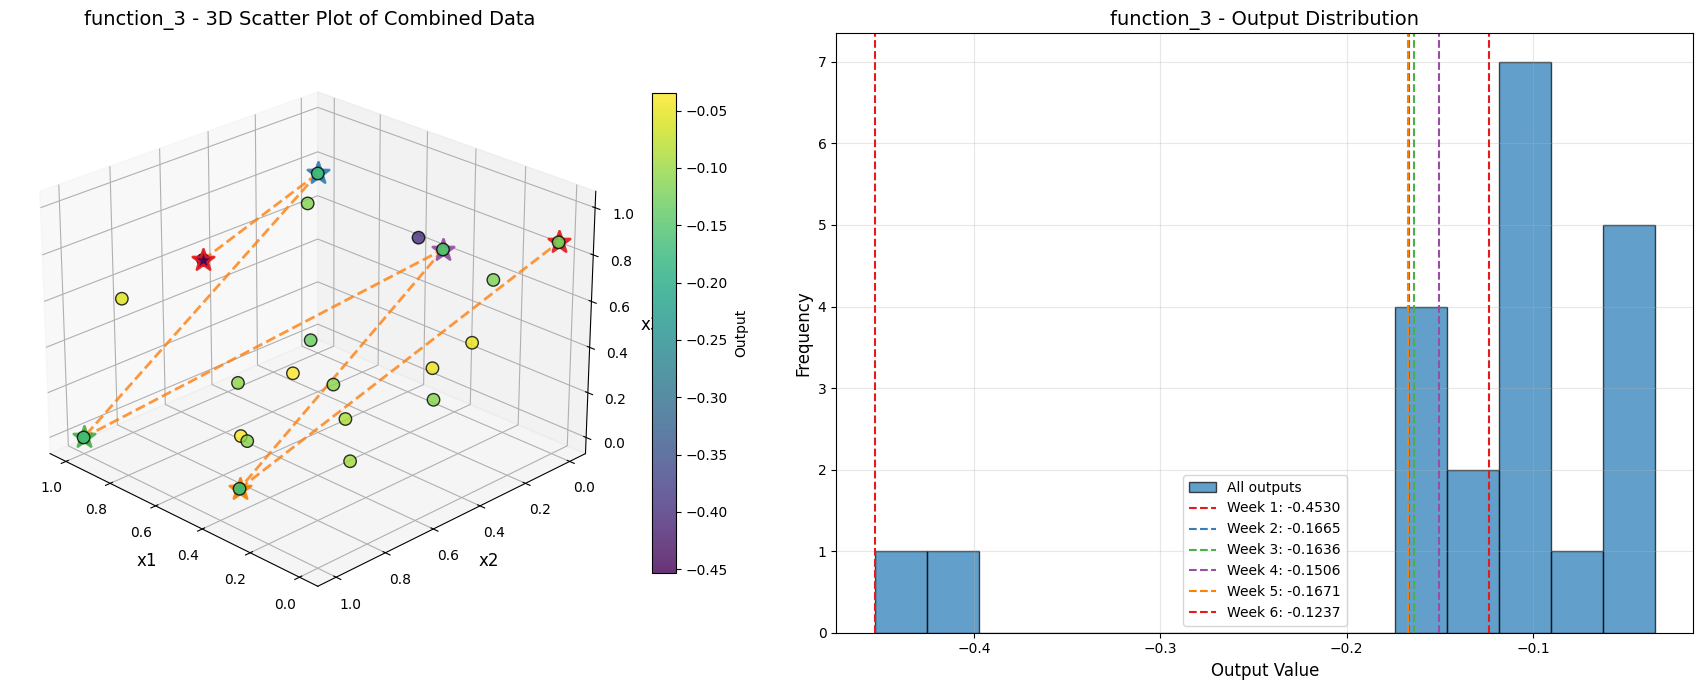

In [2]:
# Visualise past results: show all week 1–6 points before deciding on next evaluation
plot_3d_scatter_with_distribution(
    X_observed, y_observed,
    week6_input, week6_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
    ],
    connect_points=True,
    connect_color="tab:orange"
)

## Approach for Next Evaluation (Function 3 – Noisy Objective)

For the next evaluation, we will **re-run the model at the currently best-performing input configuration (the incumbent maximum)**, rather than moving immediately to a new region of the input space.

---

### Why this is necessary

The objective function for Function 3 is **noisy**, meaning that repeated evaluations at the same input can yield different outputs due to stochastic effects (e.g. randomness in training, optimisation, or evaluation). As a result:

- A single high-performing observation may be a **lucky draw** rather than a genuinely optimal configuration.
- Conversely, the Bayesian surrogate model (Gaussian Process) may **discount** a good point if it believes the observation was inflated by noise.

At present, we observe:

- A **clear empirical maximum** in the observed data.
- A Bayesian model that is **uncertain** whether this maximum reflects the true expected performance, as indicated by its posterior mean being lower than the observed value.

---

### What we are doing

We will **evaluate the objective again at the exact same input** as the current maximum. This allows us to:

1. **Estimate the expected (mean) performance** at that input.
2. **Quantify the noise level** at the point.
3. **Distinguish** between a genuinely strong configuration and a one-off noisy spike.

This step is critical in noisy optimisation: without it, the optimisation process can either over-commit to noise or prematurely abandon good regions.

---

### How this fits into Bayesian Optimisation

Bayesian Optimisation balances:

- **Exploitation** (refining promising regions), and
- **Exploration** (testing uncertain regions).

Before committing to further exploitation around a candidate maximum, we must **confirm that it is robust under noise**. Re-evaluating the incumbent is the most data-efficient way to do this and directly improves the surrogate model's calibration.

---

### Expected outcomes

- **If repeated evaluations remain close to the original maximum**, we gain confidence that this region is genuinely optimal and should be exploited further.
- **If performance degrades significantly**, this indicates the original result was noise-driven, and the optimiser's decision to explore alternative regions is justified.

In [ ]:
# Summary: next evaluation point = incumbent (re-evaluation)
# Save to results/ in same format as week5 function1_next_point.json
import json

result = {
    "function_name": function_name,
    "next_point": incumbent_input.tolist(),
    "formatted": formatted_incumbent,
    "method": "re_evaluate_incumbent",
}
Path("results").mkdir(exist_ok=True)
output_path = Path("results/function3_next_point.json")
with open(output_path, "w") as f:
    json.dump(result, f, indent=2)

print("Next evaluation point (re-run at incumbent):", formatted_incumbent)
print("Input vector:", incumbent_input)
print(f"\nResult saved to: {output_path}")

Next evaluation point (re-run at incumbent): 0.492581-0.611593-0.340176
Input vector: [0.49258141 0.61159319 0.34017639]

Result saved to: results/function3_next_point.json
